In [94]:
import h5py as h5 
import matplotlib.pyplot as plt
import numpy as np
import os, sys
# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from PMT_analysis_utils import * 
plt.style.use('../../utils/dune.mplstyle')

DEBUG_MAX = 10 

In [95]:
LRS_DIRECTORY = "/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_ambe_bin2/one_trig_32us_window/"
os.listdir(LRS_DIRECTORY)

['mpd_run_data_rctl_615_p85.FLOW.hdf5',
 'mpd_run_data_rctl_616_p34.FLOW.hdf5',
 'mpd_run_data_rctl_615_p42.FLOW.hdf5',
 'mpd_run_data_rctl_616_p90.FLOW.hdf5',
 'mpd_run_data_rctl_615_p153.FLOW.hdf5',
 'mpd_run_data_rctl_617_p8.FLOW.hdf5',
 'mpd_run_data_rctl_616_p135.FLOW.hdf5',
 'mpd_run_data_rctl_616_p122.FLOW.hdf5',
 'mpd_run_data_rctl_615_p197.FLOW.hdf5',
 'mpd_run_data_rctl_617_p3.FLOW.hdf5',
 'mpd_run_data_rctl_615_p57.FLOW.hdf5',
 'mpd_run_data_rctl_615_p117.FLOW.hdf5',
 'mpd_run_data_rctl_615_p148.FLOW.hdf5',
 'mpd_run_data_rctl_615_p23.FLOW.hdf5',
 'mpd_run_data_rctl_616_p121.FLOW.hdf5',
 'mpd_run_data_rctl_617_p44.FLOW.hdf5',
 'mpd_run_data_rctl_616_p152.FLOW.hdf5',
 'mpd_run_data_rctl_616_p130.FLOW.hdf5',
 'mpd_run_data_rctl_616_p88.FLOW.hdf5',
 'mpd_run_data_rctl_615_p184.FLOW.hdf5',
 'mpd_run_data_rctl_616_p138.FLOW.hdf5',
 'mpd_run_data_rctl_615_p172.FLOW.hdf5',
 'mpd_run_data_rctl_615_p154.FLOW.hdf5',
 'mpd_run_data_rctl_615_p155.FLOW.hdf5',
 'mpd_run_data_rctl_616_p38.

In [96]:
# Make function that does this job far file, then we iterate over each set of files
# Beware of normalization


def selection_diagnostics(waveforms):
    pmt_wvfm_v1 = np.array(waveforms[:, 0, 16, :] * (-1), dtype=np.int64) / 4
    pmt_wvfm_v2 = pmt_wvfm_v1 - np.mean(pmt_wvfm_v1[:, 0:50], axis=1, keepdims=True)
    noise_sum_all = np.sum(pmt_wvfm_v2[:, 5:100], axis=-1)
    noise_sum_fast = np.sum(pmt_wvfm_v2[:, 5:18], axis=-1)
    fast_light = np.sum(pmt_wvfm_v2[:, 105:118], axis=-1) - noise_sum_fast
    all_light = np.sum(pmt_wvfm_v2[:, 105:200], axis=-1) - noise_sum_all
    fprompt = np.full_like(fast_light, np.nan, dtype=float)
    nonzero_total = all_light != 0
    fprompt[nonzero_total] = fast_light[nonzero_total] / all_light[nonzero_total]
    thd_mask = pmt_wvfm_v2[:, 100:300] > 70
    threshold_count = np.sum(thd_mask[:, 5:120], axis=-1)
    return fprompt, threshold_count

def analysis_PMT_file(input_file):
    out_dataset = {}
    file = h5.File(input_file, "r")
    light_ev = file['light/events/data']
    waveforms = file['light/wvfm/data']['samples'][:, :, :, 0:600]
    total_evs = len(light_ev)
    good_triggers = PMT_wvfm_selection(waveforms, width=31).astype(bool)
    selection_fprompt, threshold_count = selection_diagnostics(waveforms)

    PMT_ADC = 0
    PMT_CHAN = 16 
    PMT_waveforms_pre = waveforms[:, PMT_ADC, PMT_CHAN, :]

    # Baseline correction
    PMT_waveforms = thd_correct(PMT_waveforms_pre) * -1
    amplitude = np.max(PMT_waveforms, axis=1)
    print(f"Number of light events on this file {total_evs}")
    print(f"Accepted triggers: {np.count_nonzero(good_triggers)} / {total_evs}")

    out_dataset["amplitude"] = amplitude.tolist()
    out_dataset["fprompt"] = selection_fprompt.tolist()
    out_dataset["threshold_count"] = threshold_count.tolist()
    out_dataset["accepted_amplitude"] = amplitude[good_triggers].tolist()
    out_dataset["rejected_amplitude"] = amplitude[~good_triggers].tolist()
    out_dataset["accepted_fprompt"] = selection_fprompt[good_triggers].tolist()
    out_dataset["rejected_fprompt"] = selection_fprompt[~good_triggers].tolist()
    out_dataset["accepted_threshold_count"] = threshold_count[good_triggers].tolist()
    out_dataset["rejected_threshold_count"] = threshold_count[~good_triggers].tolist()
    if np.any(good_triggers):
        first_good = np.flatnonzero(good_triggers)[0]
        out_dataset["example_good_waveform"] = PMT_waveforms[first_good].tolist()
        out_dataset["example_good_fprompt"] = float(selection_fprompt[first_good])
        out_dataset["example_good_threshold_count"] = int(threshold_count[first_good])
    else:
        out_dataset["example_good_waveform"] = None
        out_dataset["example_good_fprompt"] = None
        out_dataset["example_good_threshold_count"] = None

    if np.any(~good_triggers):
        first_bad = np.flatnonzero(~good_triggers)[0]
        out_dataset["example_bad_waveform"] = PMT_waveforms[first_bad].tolist()
        out_dataset["example_bad_fprompt"] = float(selection_fprompt[first_bad])
        out_dataset["example_bad_threshold_count"] = int(threshold_count[first_bad])
    else:
        out_dataset["example_bad_waveform"] = None
        out_dataset["example_bad_fprompt"] = None
        out_dataset["example_bad_threshold_count"] = None

    out_dataset["ntriggers"] = total_evs

    return out_dataset




In [97]:
fprompt_source_out = [] 
amplitude_source_out = [] 
accepted_amplitude_source_out = []
rejected_amplitude_source_out = []
accepted_fprompt_source_out = []
rejected_fprompt_source_out = []
accepted_threshold_count_source_out = []
rejected_threshold_count_source_out = []
example_good_waveform_source_out = None
example_bad_waveform_source_out = None
example_good_fprompt_source_out = None
example_bad_fprompt_source_out = None
example_good_threshold_count_source_out = None
example_bad_threshold_count_source_out = None
n_triggers_source_out = [] 

LRS_DIRECTORY_OUT = "/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_ambe_bin3/one_pmt_trig_no_source/"

test_index = 0 
for file in os.listdir(LRS_DIRECTORY_OUT):
    if(test_index==DEBUG_MAX):break
    print(file)
    out_data = analysis_PMT_file(LRS_DIRECTORY_OUT + file)
    fprompt_source_out.extend(out_data["fprompt"])
    amplitude_source_out.extend(out_data["amplitude"])
    accepted_amplitude_source_out.extend(out_data["accepted_amplitude"])
    rejected_amplitude_source_out.extend(out_data["rejected_amplitude"])
    accepted_fprompt_source_out.extend(out_data["accepted_fprompt"])
    rejected_fprompt_source_out.extend(out_data["rejected_fprompt"])
    accepted_threshold_count_source_out.extend(out_data["accepted_threshold_count"])
    rejected_threshold_count_source_out.extend(out_data["rejected_threshold_count"])
    if example_good_waveform_source_out is None and out_data["example_good_waveform"] is not None:
        example_good_waveform_source_out = out_data["example_good_waveform"]
        example_good_fprompt_source_out = out_data["example_good_fprompt"]
        example_good_threshold_count_source_out = out_data["example_good_threshold_count"]
    if example_bad_waveform_source_out is None and out_data["example_bad_waveform"] is not None:
        example_bad_waveform_source_out = out_data["example_bad_waveform"]
        example_bad_fprompt_source_out = out_data["example_bad_fprompt"]
        example_bad_threshold_count_source_out = out_data["example_bad_threshold_count"]
    n_triggers_source_out.append(out_data["ntriggers"])
    test_index+=1


mpd_run_data_rctl_639_p63.FLOW.hdf5
Number of light events on this file 1606
Accepted triggers: 220 / 1606
mpd_run_data_rctl_639_p70.FLOW.hdf5
Number of light events on this file 1560
Accepted triggers: 214 / 1560
mpd_run_data_rctl_639_p77.FLOW.hdf5
Number of light events on this file 1633
Accepted triggers: 241 / 1633
mpd_run_data_rctl_639_p67.FLOW.hdf5
Number of light events on this file 1572
Accepted triggers: 251 / 1572
mpd_run_data_rctl_639_p20.FLOW.hdf5
Number of light events on this file 1541
Accepted triggers: 253 / 1541
mpd_run_data_rctl_639_p6.FLOW.hdf5
Number of light events on this file 1666
Accepted triggers: 230 / 1666
mpd_run_data_rctl_639_p66.FLOW.hdf5


/global/u1/l/lmlepin/neutron_source_work/2x2_neutron_sources/AmBe/light/PMT_analysis_utils.py:278: RuntimeWarning: divide by zero encountered in divide
  def even_or_odd_indices(N, kind="even"):


Number of light events on this file 1624
Accepted triggers: 247 / 1624
mpd_run_data_rctl_639_p49.FLOW.hdf5
Number of light events on this file 1636
Accepted triggers: 244 / 1636
mpd_run_data_rctl_639_p3.FLOW.hdf5
Number of light events on this file 1601
Accepted triggers: 291 / 1601
mpd_run_data_rctl_639_p69.FLOW.hdf5
Number of light events on this file 1653
Accepted triggers: 248 / 1653


In [98]:
# Source IN

fprompt_source_in = []
amplitude_source_in = []
accepted_amplitude_source_in = []
rejected_amplitude_source_in = []
accepted_fprompt_source_in = []
rejected_fprompt_source_in = []
accepted_threshold_count_source_in = []
rejected_threshold_count_source_in = []
example_good_waveform_source_in = None
example_bad_waveform_source_in = None
example_good_fprompt_source_in = None
example_bad_fprompt_source_in = None
example_good_threshold_count_source_in = None
example_bad_threshold_count_source_in = None
n_triggers_source_in = [] 

LRS_DIRECTORY_IN = "/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_ambe_bin2/one_trig_32us_window/" 


test_index = 0 
for file in os.listdir(LRS_DIRECTORY_IN):
    if(test_index==DEBUG_MAX):break
    print(file)
    out_data = analysis_PMT_file(LRS_DIRECTORY_IN + file)
    fprompt_source_in.extend(out_data["fprompt"])
    amplitude_source_in.extend(out_data["amplitude"])
    accepted_amplitude_source_in.extend(out_data["accepted_amplitude"])
    rejected_amplitude_source_in.extend(out_data["rejected_amplitude"])
    accepted_fprompt_source_in.extend(out_data["accepted_fprompt"])
    rejected_fprompt_source_in.extend(out_data["rejected_fprompt"])
    accepted_threshold_count_source_in.extend(out_data["accepted_threshold_count"])
    rejected_threshold_count_source_in.extend(out_data["rejected_threshold_count"])
    if example_good_waveform_source_in is None and out_data["example_good_waveform"] is not None:
        example_good_waveform_source_in = out_data["example_good_waveform"]
        example_good_fprompt_source_in = out_data["example_good_fprompt"]
        example_good_threshold_count_source_in = out_data["example_good_threshold_count"]
    if example_bad_waveform_source_in is None and out_data["example_bad_waveform"] is not None:
        example_bad_waveform_source_in = out_data["example_bad_waveform"]
        example_bad_fprompt_source_in = out_data["example_bad_fprompt"]
        example_bad_threshold_count_source_in = out_data["example_bad_threshold_count"]
    n_triggers_source_in.append(out_data["ntriggers"])
    test_index+=1

mpd_run_data_rctl_615_p85.FLOW.hdf5


Number of light events on this file 3488
Accepted triggers: 1294 / 3488
mpd_run_data_rctl_616_p34.FLOW.hdf5
Number of light events on this file 3433
Accepted triggers: 1320 / 3433
mpd_run_data_rctl_615_p42.FLOW.hdf5
Number of light events on this file 3681
Accepted triggers: 1397 / 3681
mpd_run_data_rctl_616_p90.FLOW.hdf5
Number of light events on this file 3514
Accepted triggers: 1381 / 3514
mpd_run_data_rctl_615_p153.FLOW.hdf5
Number of light events on this file 3509
Accepted triggers: 1393 / 3509
mpd_run_data_rctl_617_p8.FLOW.hdf5
Number of light events on this file 3390
Accepted triggers: 1300 / 3390
mpd_run_data_rctl_616_p135.FLOW.hdf5
Number of light events on this file 3526
Accepted triggers: 1291 / 3526
mpd_run_data_rctl_616_p122.FLOW.hdf5
Number of light events on this file 3361
Accepted triggers: 1347 / 3361
mpd_run_data_rctl_615_p197.FLOW.hdf5
Number of light events on this file 3521
Accepted triggers: 1407 / 3521
mpd_run_data_rctl_617_p3.FLOW.hdf5
Number of light events on 

In [99]:
print(f"Total exposure: {90*DEBUG_MAX} s")

Total exposure: 900 s


In [100]:
print("Stats for triggers...")
print(f"Mean number of triggers: {np.mean(n_triggers_source_out)}")
print(f"Frequency: {np.mean(n_triggers_source_out)/90.} Hz")

Stats for triggers...
Mean number of triggers: 1609.2
Frequency: 17.88 Hz


In [101]:
print("Stats for triggers...")
print(f"Mean number of triggers: {np.mean(n_triggers_source_in)}")
print(f"Frequency: {np.mean(n_triggers_source_in)/90.} Hz")

Stats for triggers...
Mean number of triggers: 3492.0
Frequency: 38.8 Hz


In [102]:
def safe_divide(numerator, denominator):
    if denominator == 0:
        return np.nan
    return numerator / denominator

def format_value(value, fmt=".4f"):
    if np.isfinite(value):
        return format(value, fmt)
    return "nan"

source_live_time_s = 90.0 * len(n_triggers_source_in)
no_source_live_time_s = 90.0 * len(n_triggers_source_out)
live_time_scale = safe_divide(source_live_time_s, no_source_live_time_s)

n_source_raw = len(amplitude_source_in)
n_no_source_raw = len(amplitude_source_out)
n_source_selected = len(accepted_amplitude_source_in)
n_no_source_selected = len(accepted_amplitude_source_out)

raw_source_rate_hz = safe_divide(n_source_raw, source_live_time_s)
raw_no_source_rate_hz = safe_divide(n_no_source_raw, no_source_live_time_s)
selected_source_rate_hz = safe_divide(n_source_selected, source_live_time_s)
selected_no_source_rate_hz = safe_divide(n_no_source_selected, no_source_live_time_s)

selection_efficiency_source_sample = safe_divide(n_source_selected, n_source_raw)
background_acceptance = safe_divide(n_no_source_selected, n_no_source_raw)
background_rejection = 1.0 - background_acceptance if np.isfinite(background_acceptance) else np.nan

expected_background_pre = n_no_source_raw * live_time_scale if np.isfinite(live_time_scale) else np.nan
expected_background_post = n_no_source_selected * live_time_scale if np.isfinite(live_time_scale) else np.nan

estimated_signal_pre = n_source_raw - expected_background_pre if np.isfinite(expected_background_pre) else np.nan
estimated_signal_post = n_source_selected - expected_background_post if np.isfinite(expected_background_post) else np.nan

source_excess_efficiency = safe_divide(estimated_signal_post, estimated_signal_pre)
selected_sample_purity = safe_divide(estimated_signal_post, n_source_selected)

report_lines = [
    "PMT trigger-selection report",
    "============================",
    "",
    "Inputs and assumptions:",
    f"- Source sample live time = 90 s x {len(n_triggers_source_in)} files = {source_live_time_s:.1f} s",
    f"- No-source sample live time = 90 s x {len(n_triggers_source_out)} files = {no_source_live_time_s:.1f} s",
    "- The no-source sample is used as a background estimate.",
    "- When the live times differ, the no-source counts are scaled by (source live time)/(no-source live time).",
    "- The purity quoted below is therefore a source-excess purity, not a truth-level particle-ID purity.",
    "",
    "Raw and selected counts:",
    f"- N_source_raw = {n_source_raw}",
    f"- N_no_source_raw = {n_no_source_raw}",
    f"- N_source_selected = {n_source_selected}",
    f"- N_no_source_selected = {n_no_source_selected}",
    "",
    "Rates:",
    f"- Raw source rate = N_source_raw / T_source = {format_value(raw_source_rate_hz, '.4f')} Hz",
    f"- Raw no-source rate = N_no_source_raw / T_no_source = {format_value(raw_no_source_rate_hz, '.4f')} Hz",
    f"- Selected source rate = N_source_selected / T_source = {format_value(selected_source_rate_hz, '.4f')} Hz",
    f"- Selected no-source rate = N_no_source_selected / T_no_source = {format_value(selected_no_source_rate_hz, '.4f')} Hz",
    "",
    "Selection figures of merit:",
    f"- Selection efficiency on the source sample = N_source_selected / N_source_raw = {format_value(selection_efficiency_source_sample * 100.0, '.2f')}%",
    f"- Background acceptance = N_no_source_selected / N_no_source_raw = {format_value(background_acceptance * 100.0, '.2f')}%",
    f"- Background rejection = 1 - background acceptance = {format_value(background_rejection * 100.0, '.2f')}%",
    "",
    "Background-scaled source-excess estimate:",
    f"- Live-time scale factor = T_source / T_no_source = {format_value(live_time_scale, '.4f')}",
    f"- Expected background before selection = N_no_source_raw x scale = {format_value(expected_background_pre, '.2f')}",
    f"- Expected background after selection = N_no_source_selected x scale = {format_value(expected_background_post, '.2f')}",
    f"- Estimated source excess before selection = N_source_raw - expected_background_pre = {format_value(estimated_signal_pre, '.2f')}",
    f"- Estimated source excess after selection = N_source_selected - expected_background_post = {format_value(estimated_signal_post, '.2f')}",
    "",
    "Derived source-excess metrics:",
    f"- Source-excess efficiency = estimated_signal_post / estimated_signal_pre = {format_value(source_excess_efficiency * 100.0, '.2f')}%",
    f"- Selected-sample purity = estimated_signal_post / N_source_selected = {format_value(selected_sample_purity * 100.0, '.2f')}%",
    "",
    "Technote wording suggestion:",
    "The PMT waveform selection efficiency on the source sample is defined as N_selected(source)/N_raw(source).",
    "The no-source data are used as an estimate of the background rate, scaled by the ratio of live times when needed.",
    "A background-subtracted source excess is computed before and after selection, and the selected-sample purity is defined as",
    "(N_selected(source) - scale x N_selected(no-source)) / N_selected(source).",
    "This purity therefore quantifies the fraction of the selected sample attributable to the source excess under the no-source background model.",
]

print("\n".join(report_lines))


PMT trigger-selection report

Inputs and assumptions:
- Source sample live time = 90 s x 10 files = 900.0 s
- No-source sample live time = 90 s x 10 files = 900.0 s
- The no-source sample is used as a background estimate.
- When the live times differ, the no-source counts are scaled by (source live time)/(no-source live time).
- The purity quoted below is therefore a source-excess purity, not a truth-level particle-ID purity.

Raw and selected counts:
- N_source_raw = 34920
- N_no_source_raw = 16092
- N_source_selected = 13504
- N_no_source_selected = 2439

Rates:
- Raw source rate = N_source_raw / T_source = 38.8000 Hz
- Raw no-source rate = N_no_source_raw / T_no_source = 17.8800 Hz
- Selected source rate = N_source_selected / T_source = 15.0044 Hz
- Selected no-source rate = N_no_source_selected / T_no_source = 2.7100 Hz

Selection figures of merit:
- Selection efficiency on the source sample = N_source_selected / N_source_raw = 38.67%
- Background acceptance = N_no_source_selected 

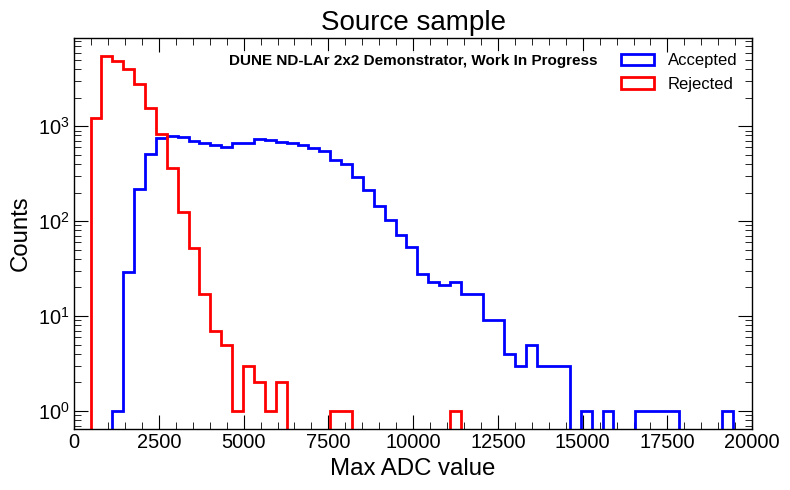

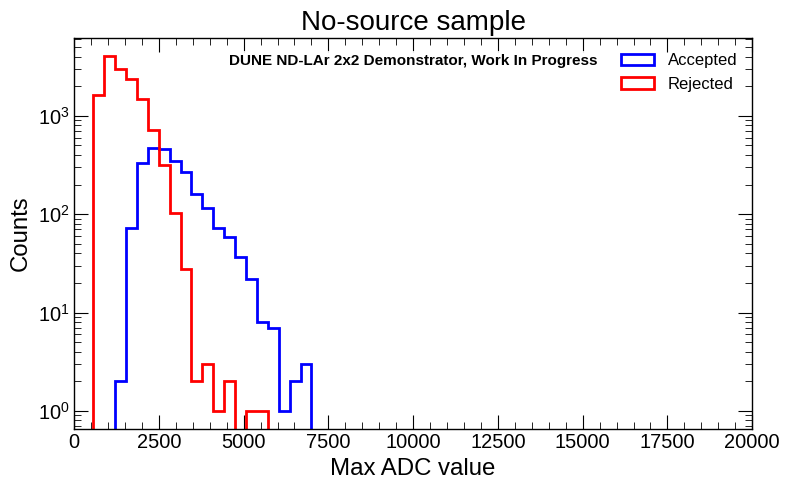

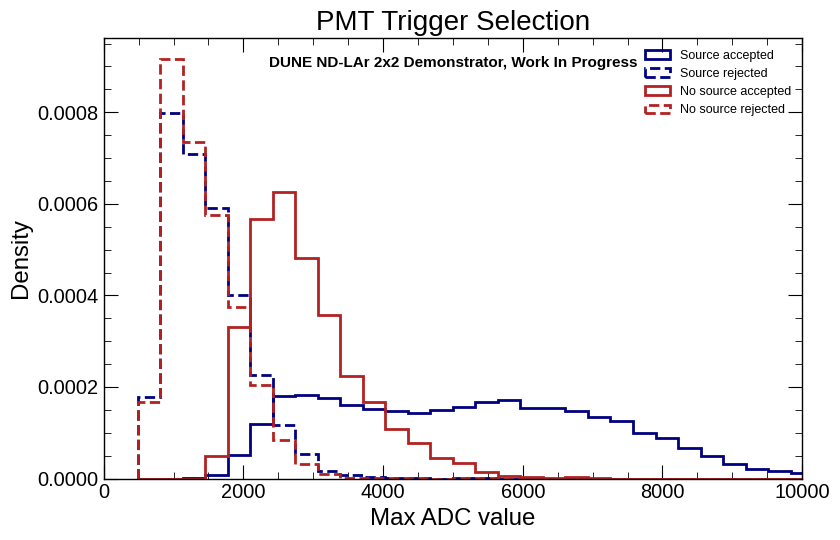

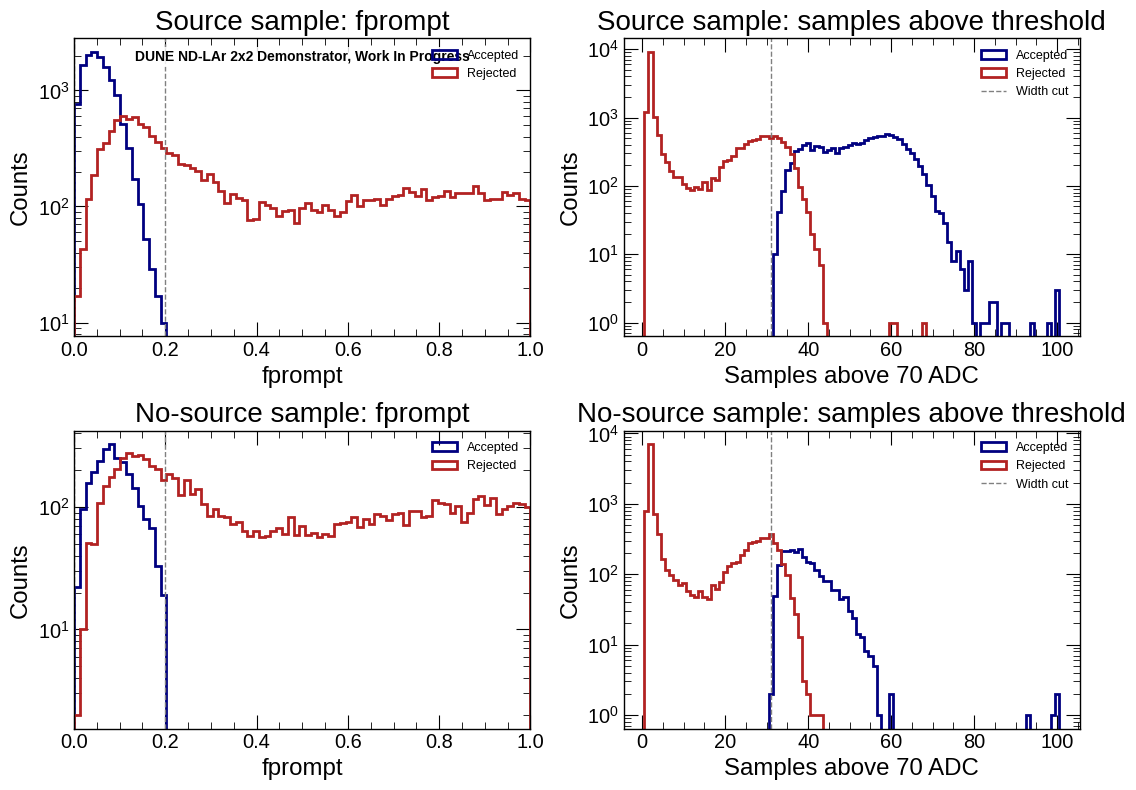

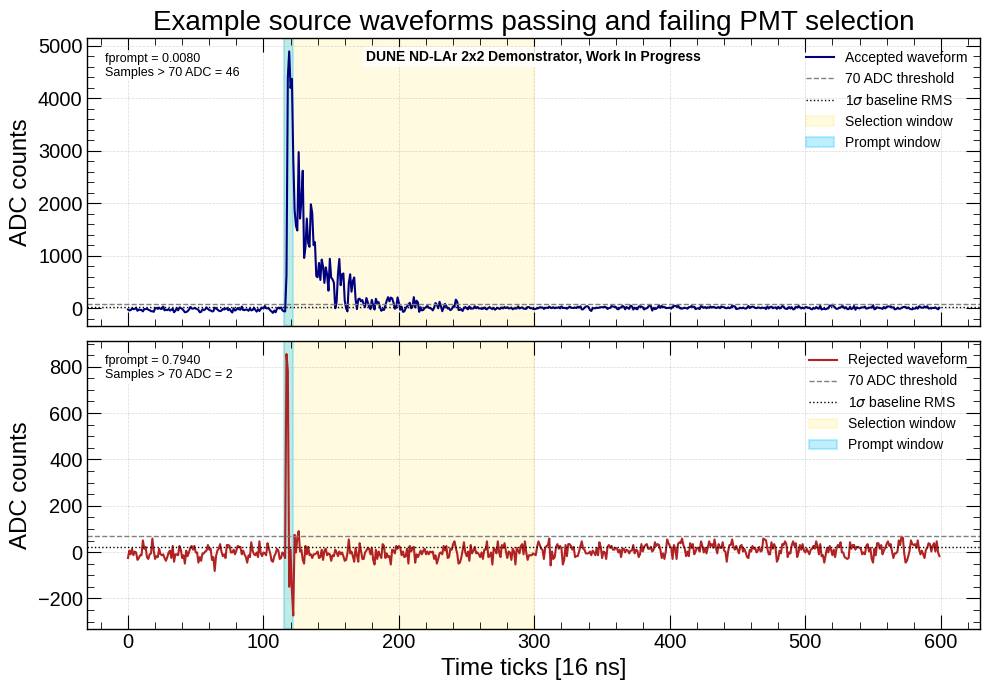

In [103]:
from pathlib import Path

FIGURE_DIR = Path("/global/homes/l/lmlepin/neutron_source_work/2x2_neutron_sources/AmBe/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def plot_selection_hist(accepted, rejected, title, filename, nbins=100):
    accepted = np.asarray(accepted)
    rejected = np.asarray(rejected)
    combined = np.concatenate([accepted, rejected])

    if combined.size == 0:
        print(f"No waveforms available for {title}")
        return

    if np.min(combined) == np.max(combined):
        bins = nbins
    else:
        bins = np.linspace(np.min(combined), np.max(combined), nbins + 1)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(accepted, bins=bins, histtype="step", linewidth=2, label="Accepted", color="blue")
    ax.hist(rejected, bins=bins, histtype="step", linewidth=2, label="Rejected", color="red")
    ax.set_xlabel("Max ADC value")
    ax.set_ylabel("Counts")
    ax.set_yscale("log")
    ax.set_xlim(0, 20000)
    ax.set_title(title)
    ax.legend()
    ax.text(
        0.5,
        0.96,
        "DUNE ND-LAr 2x2 Demonstrator, Work In Progress",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=11,
        fontweight="bold",
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none", "pad": 2},
    )
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{filename}.pdf", bbox_inches="tight")
    plt.show()

def plot_selection_density_comparison(
    source_accepted,
    source_rejected,
    no_source_accepted,
    no_source_rejected,
    title,
    filename,
    nbins=100,
):
    datasets = [
        np.asarray(source_accepted),
        np.asarray(source_rejected),
        np.asarray(no_source_accepted),
        np.asarray(no_source_rejected),
    ]
    non_empty = [dataset for dataset in datasets if dataset.size > 0]

    if not non_empty:
        print(f"No waveforms available for {title}")
        return

    combined = np.concatenate(non_empty)
    if np.min(combined) == np.max(combined):
        bins = nbins
    else:
        bins = np.linspace(np.min(combined), np.max(combined), nbins + 1)

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.hist(source_accepted, bins=bins, density=True, histtype="step", linewidth=2, color="navy", label="Source accepted")
    ax.hist(source_rejected, bins=bins, density=True, histtype="step", linewidth=2, color="navy", linestyle="--", label="Source rejected")
    ax.hist(no_source_accepted, bins=bins, density=True, histtype="step", linewidth=2, color="firebrick", label="No source accepted")
    ax.hist(no_source_rejected, bins=bins, density=True, histtype="step", linewidth=2, color="firebrick", linestyle="--", label="No source rejected")
    ax.set_xlabel("Max ADC value")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 10000)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.text(
        0.5,
        0.96,
        "DUNE ND-LAr 2x2 Demonstrator, Work In Progress",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=11,
        fontweight="bold",
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none", "pad": 2},
    )
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{filename}.pdf", bbox_inches="tight")
    plt.show()

def plot_selection_diagnostic_summary(
    source_accepted_fprompt,
    source_rejected_fprompt,
    source_accepted_threshold,
    source_rejected_threshold,
    no_source_accepted_fprompt,
    no_source_rejected_fprompt,
    no_source_accepted_threshold,
    no_source_rejected_threshold,
    filename,
):
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))

    fprompt_sets = [
        np.asarray(source_accepted_fprompt),
        np.asarray(source_rejected_fprompt),
        np.asarray(no_source_accepted_fprompt),
        np.asarray(no_source_rejected_fprompt),
    ]
    fprompt_sets = [arr[np.isfinite(arr)] for arr in fprompt_sets if np.asarray(arr).size > 0]
    fprompt_low = 0.0
    fprompt_high = 1.0
    fprompt_bins = np.linspace(fprompt_low, fprompt_high, 80)

    threshold_sets = [
        np.asarray(source_accepted_threshold),
        np.asarray(source_rejected_threshold),
        np.asarray(no_source_accepted_threshold),
        np.asarray(no_source_rejected_threshold),
    ]
    threshold_sets = [arr for arr in threshold_sets if arr.size > 0]
    if threshold_sets:
        combined_threshold = np.concatenate(threshold_sets)
        threshold_bins = np.arange(np.min(combined_threshold), np.max(combined_threshold) + 2) - 0.5
    else:
        threshold_bins = 80

    axes[0, 0].hist(source_accepted_fprompt, bins=fprompt_bins, histtype="step", linewidth=2, color="navy", label="Accepted")
    axes[0, 0].hist(source_rejected_fprompt, bins=fprompt_bins, histtype="step", linewidth=2, color="firebrick", label="Rejected")
    axes[0, 0].axvline(0.001, color="gray", linestyle="--", linewidth=1)
    axes[0, 0].axvline(0.2, color="gray", linestyle="--", linewidth=1)
    axes[0, 0].set_title("Source sample: fprompt")
    axes[0, 0].set_xlabel("fprompt")
    axes[0, 0].set_ylabel("Counts")
    axes[0, 0].set_xlim(fprompt_low, fprompt_high)
    axes[0, 0].set_yscale("log")
    axes[0, 0].legend(fontsize=9)

    axes[0, 1].hist(source_accepted_threshold, bins=threshold_bins, histtype="step", linewidth=2, color="navy", label="Accepted")
    axes[0, 1].hist(source_rejected_threshold, bins=threshold_bins, histtype="step", linewidth=2, color="firebrick", label="Rejected")
    axes[0, 1].axvline(31, color="gray", linestyle="--", linewidth=1, label="Width cut")
    axes[0, 1].set_title("Source sample: samples above threshold")
    axes[0, 1].set_xlabel("Samples above 70 ADC")
    axes[0, 1].set_ylabel("Counts")
    axes[0, 1].set_yscale("log")
    axes[0, 1].legend(fontsize=9)

    axes[1, 0].hist(no_source_accepted_fprompt, bins=fprompt_bins, histtype="step", linewidth=2, color="navy", label="Accepted")
    axes[1, 0].hist(no_source_rejected_fprompt, bins=fprompt_bins, histtype="step", linewidth=2, color="firebrick", label="Rejected")
    axes[1, 0].axvline(0.001, color="gray", linestyle="--", linewidth=1)
    axes[1, 0].axvline(0.2, color="gray", linestyle="--", linewidth=1)
    axes[1, 0].set_title("No-source sample: fprompt")
    axes[1, 0].set_xlabel("fprompt")
    axes[1, 0].set_ylabel("Counts")
    axes[1, 0].set_xlim(fprompt_low, fprompt_high)
    axes[1, 0].set_yscale("log")
    axes[1, 0].legend(fontsize=9)

    axes[1, 1].hist(no_source_accepted_threshold, bins=threshold_bins, histtype="step", linewidth=2, color="navy", label="Accepted")
    axes[1, 1].hist(no_source_rejected_threshold, bins=threshold_bins, histtype="step", linewidth=2, color="firebrick", label="Rejected")
    axes[1, 1].axvline(31, color="gray", linestyle="--", linewidth=1, label="Width cut")
    axes[1, 1].set_title("No-source sample: samples above threshold")
    axes[1, 1].set_xlabel("Samples above 70 ADC")
    axes[1, 1].set_ylabel("Counts")
    axes[1, 1].set_yscale("log")
    axes[1, 1].legend(fontsize=9)

    axes[0, 0].text(
        0.5,
        0.96,
        "DUNE ND-LAr 2x2 Demonstrator, Work In Progress",
        transform=axes[0, 0].transAxes,
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none", "pad": 2},
    )
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{filename}.pdf", bbox_inches="tight")
    plt.show()

def plot_example_waveforms(
    good_waveform,
    bad_waveform,
    good_fprompt,
    bad_fprompt,
    good_threshold_count,
    bad_threshold_count,
    title,
    filename,
):
    if good_waveform is None or bad_waveform is None:
        print(f"Missing waveform examples for {title}")
        return

    good_waveform = np.asarray(good_waveform)
    bad_waveform = np.asarray(bad_waveform)
    time_ticks = np.arange(len(good_waveform))
    prompt_window = (115, 122)
    total_window = (115, 300)

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    for ax, waveform, label, color, fprompt_value, threshold_value in [
        (axes[0], good_waveform, "Accepted waveform", "navy", good_fprompt, good_threshold_count),
        (axes[1], bad_waveform, "Rejected waveform", "firebrick", bad_fprompt, bad_threshold_count),
    ]:
        noise_std = np.std(waveform[0:30])
        ax.plot(time_ticks, waveform, color=color, linewidth=1.5, label=label)
        ax.axhline(y=70, color="gray", linestyle="--", linewidth=1, label="70 ADC threshold")
        ax.axhline(y=noise_std, color="black", linestyle=":", linewidth=1, label=r"1$\sigma$ baseline RMS")
        ax.axvspan(total_window[0], total_window[1], color="gold", alpha=0.12, label="Selection window")
        ax.axvspan(prompt_window[0], prompt_window[1], color="deepskyblue", alpha=0.25, label="Prompt window")
        ax.set_ylabel("ADC counts")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc="upper right", fontsize=10)
        ax.text(
            0.02,
            0.95,
            f"fprompt = {fprompt_value:.4f}\nSamples > 70 ADC = {threshold_value}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none", "pad": 2},
        )

    axes[0].set_title(title)
    axes[0].text(
        0.5,
        0.96,
        "DUNE ND-LAr 2x2 Demonstrator, Work In Progress",
        transform=axes[0].transAxes,
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none", "pad": 2},
    )
    axes[1].set_xlabel("Time ticks [16 ns]")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{filename}.pdf", bbox_inches="tight")
    plt.show()

plot_selection_hist(
    accepted_amplitude_source_in,
    rejected_amplitude_source_in,
    "Source sample",
    "source_sample_max_adc_selection",
)

plot_selection_hist(
    accepted_amplitude_source_out,
    rejected_amplitude_source_out,
    "No-source sample",
    "no_source_sample_max_adc_selection",
)

plot_selection_density_comparison(
    accepted_amplitude_source_in,
    rejected_amplitude_source_in,
    accepted_amplitude_source_out,
    rejected_amplitude_source_out,
    "PMT Trigger Selection",
    "source_no_source_max_adc_density_comparison",
)

plot_selection_diagnostic_summary(
    accepted_fprompt_source_in,
    rejected_fprompt_source_in,
    accepted_threshold_count_source_in,
    rejected_threshold_count_source_in,
    accepted_fprompt_source_out,
    rejected_fprompt_source_out,
    accepted_threshold_count_source_out,
    rejected_threshold_count_source_out,
    "pmt_selection_diagnostic_summary",
)

plot_example_waveforms(
    example_good_waveform_source_in,
    example_bad_waveform_source_in,
    example_good_fprompt_source_in,
    example_bad_fprompt_source_in,
    example_good_threshold_count_source_in,
    example_bad_threshold_count_source_in,
    "Example source waveforms passing and failing PMT selection",
    "source_example_good_bad_waveforms",
)


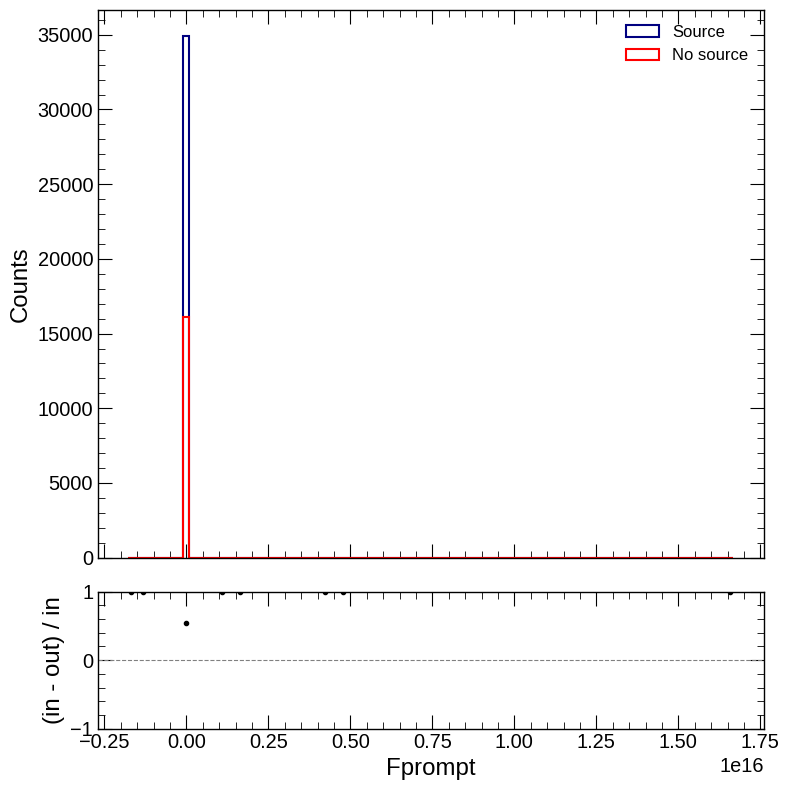

In [104]:
import numpy as np
import matplotlib.pyplot as plt

nbins = 100

fprompt_source_in_valid = np.asarray(fprompt_source_in)
fprompt_source_out_valid = np.asarray(fprompt_source_out)
fprompt_source_in_valid = fprompt_source_in_valid[np.isfinite(fprompt_source_in_valid)]
fprompt_source_out_valid = fprompt_source_out_valid[np.isfinite(fprompt_source_out_valid)]

if fprompt_source_in_valid.size == 0 or fprompt_source_out_valid.size == 0:
    raise ValueError("No finite fprompt values available for histogramming")

# Compute histograms
counts_in, bin_edges = np.histogram(fprompt_source_in_valid, bins=nbins)
counts_out, _ = np.histogram(fprompt_source_out_valid, bins=bin_edges)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Ratio
ratio = np.zeros_like(counts_in, dtype=float)
nonzero = counts_in > 0
ratio[nonzero] = (counts_in[nonzero] - counts_out[nonzero]) / counts_in[nonzero]
ratio[~nonzero] = np.nan

fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [4, 1]}
)

# Top panel: histograms
ax1.hist(fprompt_source_in_valid, bins=bin_edges, histtype="step", label="Source",color='navy')
ax1.hist(fprompt_source_out_valid, bins=bin_edges, histtype="step", label="No source",color='red')
ax1.set_ylabel("Counts")
ax1.legend()

# Bottom panel: ratio
ax2.plot(bin_centers, ratio, marker='o', linestyle='-', markersize=3)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel("Fprompt")
ax2.set_ylabel("(in - out) / in")
ax2.set_ylim(-1, 1)

plt.tight_layout()
plt.show()


Purity above 5000 ADC = 99.23%


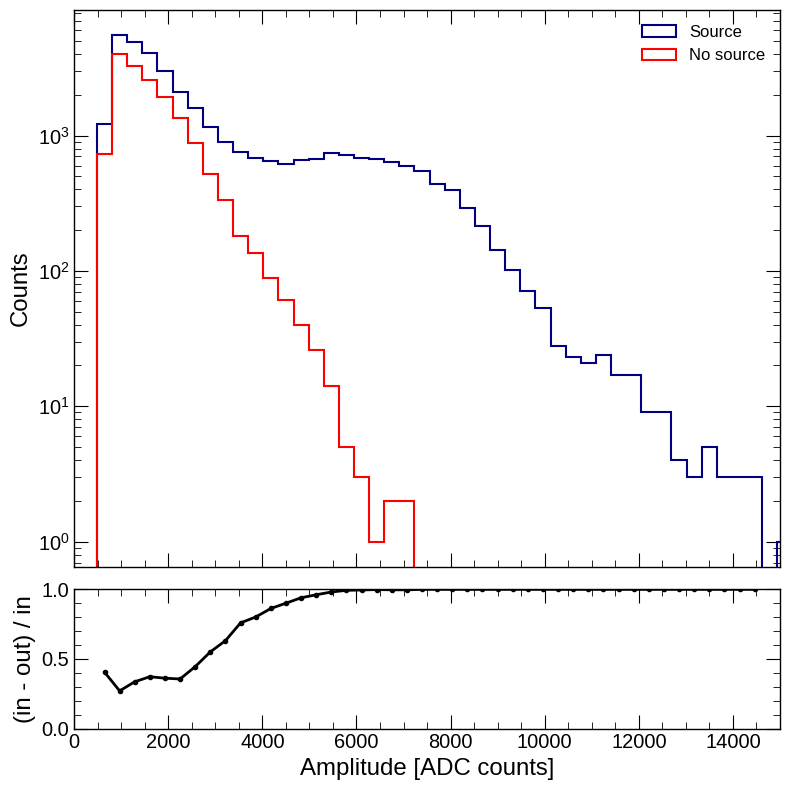

In [105]:

# --- Histogram settings ---
nbins = 100
threshold = 5000  # ADC cut for purity

# Compute histograms (shared bin edges)
counts_in, bin_edges = np.histogram(amplitude_source_in, bins=nbins)
counts_out, _ = np.histogram(amplitude_source_out, bins=bin_edges)

# Bin centers
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# --- Compute purity ---
# Identify bins where bin center is above the threshold
above_cut = bin_centers > threshold

# Sums for purity
sum_in = np.sum(counts_in[above_cut])
sum_out = np.sum(counts_out[above_cut])

if sum_in > 0:
    purity = ((sum_in - sum_out) / sum_in) * 100
else:
    purity = np.nan

print(f"Purity above {threshold} ADC = {purity:.2f}%")

# --- Compute the ratio (in - out)/in ---
ratio = np.zeros_like(counts_in, dtype=float)
nonzero = counts_in > 0
ratio[nonzero] = (counts_in[nonzero] - counts_out[nonzero]) / counts_in[nonzero]
ratio[~nonzero] = np.nan

# --- Figure with height ratio 4:1 ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [4, 1]}
)

# --- Top panel: histograms ---
ax1.hist(amplitude_source_in, bins=bin_edges, histtype="step", label="Source",color='navy')
ax1.hist(amplitude_source_out, bins=bin_edges, histtype="step", label="No source",color='red')
ax1.set_ylabel("Counts")
ax1.set_xlim(0.,15000)
ax1.set_yscale('log')
ax1.legend()

# --- Bottom panel: ratio plot ---
ax2.plot(bin_centers, ratio, marker='o', linestyle='-', markersize=3)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel("Amplitude [ADC counts]")
ax2.set_ylabel("(in - out) / in")
ax2.set_ylim(0, 1)
ax2.set_xlim(0.,15000)

plt.tight_layout()
plt.show()



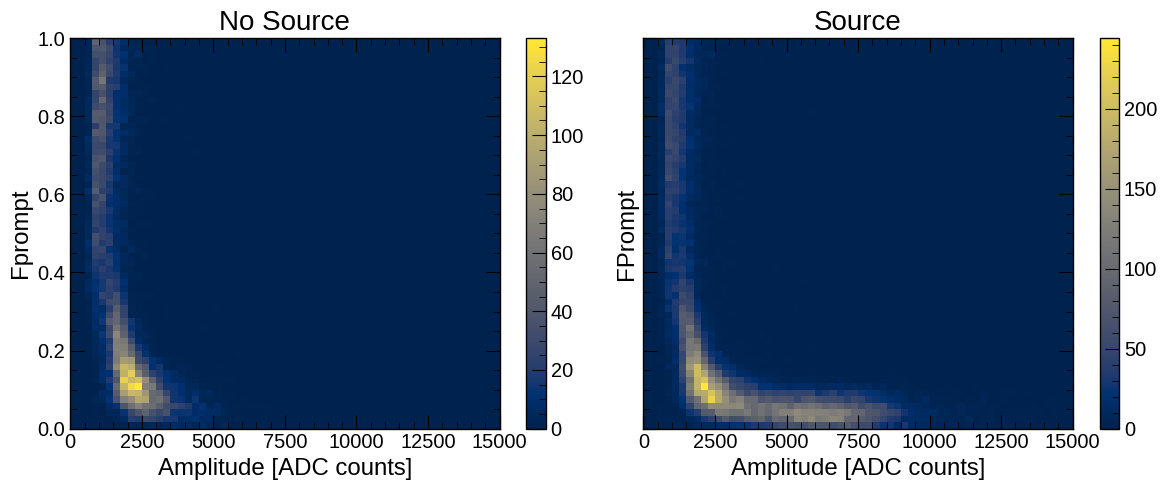

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# User-chosen axis ranges
# -------------------------------
# Example (change these values):
xrange = (0, 15000)      # amplitude range
yrange = (0.0, 1.0)     # fprompt range
# -------------------------------

# Number of bins
nbins_amp = 60
nbins_fpr = 60

# Construct bin edges using provided axis limits
xedges = np.linspace(xrange[0], xrange[1], nbins_amp + 1)
yedges = np.linspace(yrange[0], yrange[1], nbins_fpr + 1)

valid_out = np.isfinite(amplitude_source_out) & np.isfinite(fprompt_source_out)
valid_in = np.isfinite(amplitude_source_in) & np.isfinite(fprompt_source_in)

# Compute 2D histograms using the chosen ranges
H_out, _, _ = np.histogram2d(
    np.asarray(amplitude_source_out)[valid_out],
    np.asarray(fprompt_source_out)[valid_out],
    bins=[xedges, yedges]
)

H_in, _, _ = np.histogram2d(
    np.asarray(amplitude_source_in)[valid_in],
    np.asarray(fprompt_source_in)[valid_in],
    bins=[xedges, yedges]
)

# --- Create figure with two panels ---
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 5), sharex=True, sharey=True
)

# --- Left panel: No source ---
mesh1 = ax1.pcolormesh(
    xedges, yedges, H_out.T,
    shading='auto'
)
ax1.set_title("No Source",size=20)
ax1.set_xlabel("Amplitude [ADC counts]")
ax1.set_ylabel("Fprompt")
cbar1 = plt.colorbar(mesh1, ax=ax1)

# --- Right panel: Source ---
mesh2 = ax2.pcolormesh(
    xedges, yedges, H_in.T,
    shading='auto'
)
ax2.set_title("Source",size=20)
ax2.set_ylabel("FPrompt")
ax2.set_xlabel("Amplitude [ADC counts]")
cbar2 = plt.colorbar(mesh2, ax=ax2)

# Apply the axis ranges
ax1.set_xlim(xrange)
ax1.set_ylim(yrange)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1843359/975362053.py:36: RuntimeWarning: divide by zero encountered in divide
  H_diff = (H_in - H_out)/H_in
/tmp/ipykernel_1843359/975362053.py:36: RuntimeWarning: invalid value encountered in divide
  H_diff = (H_in - H_out)/H_in


(array([ 0,  0,  0, ..., 99, 99, 99]), array([ 0,  1,  2, ..., 97, 98, 99]))


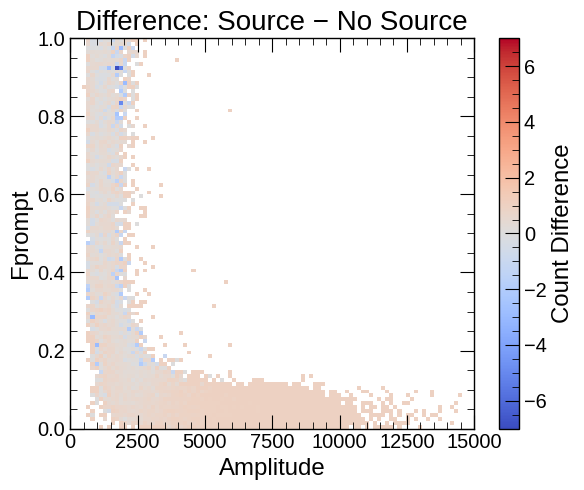

In [107]:
import matplotlib.colors as colors
# -------------------------------
# User-chosen axis ranges
# -------------------------------
xrange = (0, 15000)      # amplitude limits
yrange = (0.0, 1.0)     # fprompt limits
# -------------------------------

# Number of bins
nbins_amp = 100
nbins_fpr = 100

# Construct bin edges
xedges = np.linspace(xrange[0], xrange[1], nbins_amp + 1)
yedges = np.linspace(yrange[0], yrange[1], nbins_fpr + 1)

valid_out = np.isfinite(amplitude_source_out) & np.isfinite(fprompt_source_out)
valid_in = np.isfinite(amplitude_source_in) & np.isfinite(fprompt_source_in)

# Compute 2D histograms
H_out, _, _ = np.histogram2d(
    np.asarray(amplitude_source_out)[valid_out],
    np.asarray(fprompt_source_out)[valid_out],
    bins=[xedges, yedges]
)

H_in, _, _ = np.histogram2d(
    np.asarray(amplitude_source_in)[valid_in],
    np.asarray(fprompt_source_in)[valid_in],
    bins=[xedges, yedges]
)



# Difference histogram
H_diff = (H_in - H_out)/H_in

print(np.where(H_diff!=np.isnan))
# -------------------------------------------------------
# Make a standalone figure for the difference heatmap
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

# Center colormap around zero
#max_abs = np.max(np.abs(H_diff))

mesh = ax.pcolormesh(
    xedges, yedges, H_diff.T,
    shading='auto',
    cmap='coolwarm',
    norm=colors.CenteredNorm()  # symmetric colormap around zero
)

ax.set_title("Difference: Source − No Source")
ax.set_xlabel("Amplitude")
ax.set_ylabel("Fprompt")
ax.set_xlim(xrange)
ax.set_ylim(yrange)

cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label("Count Difference")

plt.tight_layout()
plt.show()
